# **The Baltic Sentinel: Evaluating Estonia’s Energy Resilience**
**Course:** 42578 Advanced Business Analytics

---

## **1. Introduction - Ursula** 

Text about introduction

*  why is it important now? -> wars, independence 


In [1]:
# Standard Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Note: Custom helper functions and modular scripts (STGNN, PowerScaler, etc.) 
# are hosted in the sandra359/advanced_ba repository.
import sys
import os

# Plotting configuration
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## **2. Data - Sofie**

Our analysis uses a modular pipeline to isolate and recombine the two sides of the grid equation. 

### **2.1 Data Sources**
*   **Grid Operations (Elering):** Hourly production, consumption, and cross-border flow data[cite: 3].
*   **Market Pricing (Nord Pool):** Day-Ahead clearing prices for the EE, FI, and LV bidding zones[cite: 3].
*   **Environment (OpenWeather API):** Historical temperature and wind speeds for specific coordinates[cite: 3].

### **2.2 Wind Capacity Scenarios** 
*   **Baseline (Current):** **694 MW** of grid-connected wind[cite: 1].
*   **Scenario A (Established):** Adding **323 MW** from Pärnu and Aidu[cite: 1].
*   **Scenario B (Full Pipeline):** Adding a total of **887 MW** of new capacity[cite: 1].

In [ ]:
# Define capacities based on Project Advanced BA
CURRENT_WIND_MW = 694.0
SCENARIO_A_MW = CURRENT_WIND_MW + 323.0
SCENARIO_B_MW = CURRENT_WIND_MW + 887.0

# Physical Grid Limits (MW)
ESTLINK_CAPACITY = 1016  
LATVIA_CAPACITY = 700    

print(f"Baseline Wind: {CURRENT_WIND_MW} MW")
print(f"Scenario A (Established) Wind: {SCENARIO_A_MW} MW")
print(f"Scenario B (Full Pipeline) Wind: {SCENARIO_B_MW} MW")

## **3. Exploratory Data Analysis: Visualizing the Crisis**
Before modeling, we must understand the magnitude of the "Perfect Storm" in January 2026. Here, we visualize the temperature-demand trap, the EstLink failure cliff, and flow divergence.

The plot below shows monthly average energy flows and production in Estonia from 2019 to 2026.

/var/folders/t7/k_81cy8x6zg28rjf0wl09fl00000gn/T/ipykernel_2079/3314028069.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  (-df_electricity["flow_('ee', 'fi')"]).resample('M').mean().plot(figsize=(12, 6), label='FI to EE')
/var/folders/t7/k_81cy8x6zg28rjf0wl09fl00000gn/T/ipykernel_2079/3314028069.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_electricity["system_production"].resample('M').mean().plot(figsize=(12, 6), label='EE production')
/var/folders/t7/k_81cy8x6zg28rjf0wl09fl00000gn/T/ipykernel_2079/3314028069.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  (-df_electricity["flow_('ee', 'lv')"]).resample('M').mean().plot(figsize=(12, 6), label='LV to EE')


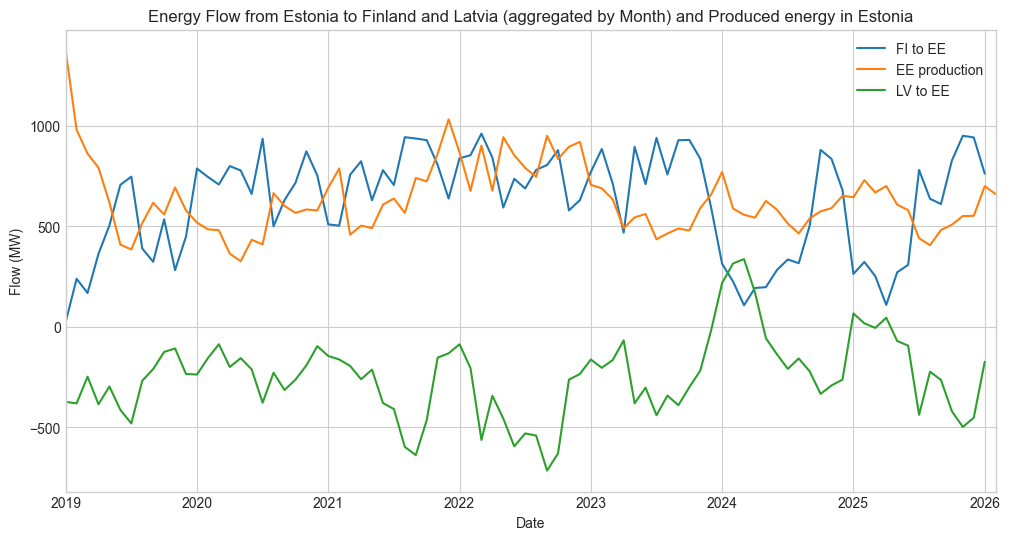

In [9]:
# How much import we have right now
df_electricity = pd.read_csv('project/elering_daily.csv')
df_electricity['timestamp'] = pd.to_datetime(df_electricity['timestamp'])
df_electricity.index = df_electricity['timestamp']
df_electricity.drop(columns=['timestamp'], inplace=True)
(-df_electricity["flow_('ee', 'fi')"]).resample('M').mean().plot(figsize=(12, 6), label='FI to EE')

df_electricity["system_production"].resample('M').mean().plot(figsize=(12, 6), label='EE production')



(-df_electricity["flow_('ee', 'lv')"]).resample('M').mean().plot(figsize=(12, 6), label='LV to EE')

plt.xlabel('Date')
plt.ylabel('Flow (MW)')
plt.title('Energy Flow from Estonia to Finland and Latvia (aggregated by Month) and Produced energy in Estonia')
plt.legend()
plt.show()

**FI to EE (blue)** — The flow from Finland to Estonia is generally positive,
ranging between 500–950 MW for most of the period, indicating Estonia is a
net **importer** from Finland. A notable drop occurs around 2024, likely
related to the Baltic states' desynchronization from the Russian BRELL grid on February 8, 2025
([ERR News, 2024](https://news.err.ee/1609367879/baltics-to-leave-brell-electricity-grid-at-start-of-february-2025);
[Wikipedia](https://en.wikipedia.org/wiki/Baltic_states_synchronization_with_CESA)).

**EE production (orange)** — Estonia's system production starts high
(~1300 MW) in 2019 and declines significantly toward 2021–2022,
stabilizing around 500–900 MW. This likely reflects the phase-out of
oil shale power plants.

**LV to EE (green)** — The flow from Latvia to Estonia is consistently
negative until ~2024, meaning Estonia was a net **exporter** to Latvia
throughout that period. From 2024 onward the flow turns positive —
Estonia begins importing from Latvia — likely connected to the Baltic
synchronization with the Continental European grid in February 2025,
when the Baltic states disconnected from BRELL.

The most striking pattern is the structural **shift around 2024–2025**,
where flow patterns change significantly on both interconnectors.

In [ ]:
# Load historical data (placeholder paths - update with actual data from sandra359/advanced_ba)
# df_historical = pd.read_csv('data/historical_jan2026.csv')

# TODO: Plot 1: Temperature vs. Consumption Spikes
# TODO: Plot 2: EstLink Flow (showing the drop to 0 MW)
# TODO: Plot 3: Nord Pool Price Divergence (EE vs FI vs LV)

### **TODO:**

* how much import we have right now (plots) - Sandra & Tomas
* Estonian electricity generation by type - Ursula 
* Prices over time - Tomas

## **4. Demand Analysis: Probabilistic Forecasting - Sofie**

Resilience is tested against extremes. We use an **ARIMAX** model to predict hourly consumption, accounting for temperature and temporal features[cite: 3].

To identify "edge-case" demand, we perform a **Monte Carlo simulation** using the model’s residual standard deviation. This allows us to extract a **P95 Worst-Case Demand** curve, ensuring our stress test targets a 1-in-100-year consumption spike[cite: 3].

In [ ]:
# The ARIMAX model and Monte Carlo simulation logic are executed in Demand.py.
# Here, we load the pre-calculated P95 Worst-Case Demand curve for January 2026.

# demand_df = pd.read_csv("data/demand_p95_jan2026.csv")
# demand_df['timestamp'] = pd.to_datetime(demand_df['timestamp'])

# TODO: Visualize the P50 (Average) vs P95 (Worst-Case) Demand Forecast

### TODO

* add all the text from Sofie

## **5. Wind Counterfactual Simulation - Ursula**

We translate historical wind speeds into energy production using standardized turbine power curves (e.g., Vestas V150)[cite: 3]. We adjust for air density based on temperature.

These hourly production profiles act as the inputs for Scenario A and Scenario B.

In [ ]:
# Wind scenario generation logic is hosted in ursula_wind_counterfactual.ipynb
# Load the pre-calculated wind production scenarios

# df_wind = pd.read_csv("data/wind_production_scenarios.csv")

# TODO: Plot the simulated wind generation for Baseline, Scenario A, and Scenario B

## **6. Supply Analysis: Spatio-Temporal GNN - Sandra & Tomas**

The Estonian grid is a geographic network. We use a **Spatio-Temporal Graph Neural Network (ST-GNN)** to model how energy flows and market prices propagate across nodes.

*   **Quantile Regression:** The GNN natively outputs **P10 (Worst-Case Supply)**, P50, and P90, handling supply-side uncertainty without a second Monte Carlo simulation. 
*   **"Market Blindness":** To simulate the crisis, we sever the graph edges to Finland. This forces the model to predict domestic production in **Island Mode**, reacting only to local weather rather than Nordic market prices.

---

### **6.1 Supply vs Demand: Timeline Analysis**

The figure below shows the hourly supply forecast (P10, P50, P90 confidence bands) against the demand profile (P50 median + P95 worst-case) for each scenario across January 2026.

**S1 (Full Grid):** With historical market flows intact, Estonia has reliable supply with margin above typical demand (~900 MW). The P10 worst-case rarely dips below 800 MW.

**S2 (Isolated, No Wind):** When EstLink is severed, supply collapses below 700 MW during most hours. Demand spikes create severe deficits—the 900 MW consumption line sits far above available production.

**S3 (Isolated + Scenario A, +323 MW Wind):** Adding established wind plans (Pärnu, Aidu) improves supply to ~900 MW median, but worst-case (P10) remains vulnerable around 500–600 MW. Still insufficient for independence.

**S4 (Isolated + Scenario B, +887 MW Wind):** Full pipeline investment nearly closes the gap. Median supply reaches ~1000 MW, covering typical demand. However, P10 worst-case hours still show 200–300 MW deficits.

![Supply vs Demand - January 2026](../figures/resilience_supply_vs_demand.png)

---

### **6.2 Scenario Comparison Summary**

This summary table compares the resilience metrics across all four scenarios.

**Mean Deficit Risk (%):** The percentage of hours where supply falls below demand. S1 has minimal risk (24.8%) due to imports. S2 jumps to 99.2% — isolation is catastrophic. S3 and S4 reduce this risk to 96.1% and 86.5% respectively through wind investment.

**Mean Surplus (MW):** The average hourly margin between supply (P50) and demand. S1 has +99 MW cushion. S2 has -483 MW deficit (impossible without blackouts). S3 improves to -415 MW, S4 to -310 MW. Even S4 cannot achieve full independence—strategic reserves remain critical.

![Scenario Comparison Summary](../figures/resilience_summary.png)

---

### **6.3 Hourly Deficit Risk Timeline**

This chart shows when and how severe deficits occur across January 2026, measured as the percentage of demand that cannot be met by domestic production.

**S1 (Green):** Deficit risk stays below 50%, clustered in early January cold snaps. Imports absorb all shortfalls.

**S2 (Red):** Nearly 100% of hours show deficits—no scenario is viable in island mode without massive wind. The flat red line illustrates the irreducible mismatch between Estonia's demand and isolated production.

**S3 (Orange):** Wind investment reduces deficit risk to ~60–80% during peak crisis hours (Jan 2–8), but recovery is incomplete. Late-month days show improvement as demand softens.

**S4 (Yellow):** Approaches S1-like conditions, with deficit risk averaging 10–40% during the month. However, multiple "spike" days still show 80%+ deficits, confirming that wind alone cannot guarantee autonomy.

![Hourly Deficit Risk](../figures/resilience_deficit_risk.png)

---

### **6.4 Uncertainty Analysis: Monte Carlo Demand Simulation**

The "fan" plots below show the range of possible supply-demand balances when we account for demand uncertainty from 1,000 Monte Carlo simulations of the ARIMAX demand model.

**Upper band (light color):** Best-case scenario where demand is low + supply is high.  
**Central line (dark):** Most likely balance (P50 supply vs median demand).  
**Lower band (dark color):** Worst-case scenario where demand spikes + supply drops.

**S1 (Green):** Surplus remains positive across all simulations. Even the worst-case band stays above zero, confirming S1's resilience with imports.

**S2 (Red):** Deficit is universal and severe (–500 to –1000 MW). The entire fan sits below zero—there is no demand scenario under which isolated Estonia can self-supply without wind.

**S3 (Orange):** Median scenario approaches break-even, but the lower tail remains deeply negative (–800 to –1200 MW). Worst-case demand spikes create blackouts even with +323 MW wind.

**S4 (Yellow):** The lower tail approaches zero and occasionally turns positive, indicating that on low-demand days with good wind, Estonia approaches self-sufficiency. However, persistent deficits during demand peaks confirm that **887 MW wind + no reserves = partial resilience.**

![MC Surplus Fan - Uncertainty from Demand Simulations](../figures/resilience_mc_surplus_fan.png)

---

### **Key Findings from GNN Supply Analysis**

1. **Weather Dominance:** January 2026 wind generation was ~50% below the 20-year average (CF 15.2% vs. 30.4%). This adversity reveals Estonia's core vulnerability: even Scenario B cannot fully compensate for a "Perfect Storm" of low wind + cold demand.

2. **S3 (Established Plans) is Necessary but Insufficient:** The +323 MW from Pärnu and Aidu represents ~50% of the path to independence, reducing crisis hours from 744 (S2) to ~280 (S3). However, this leaves Estonia exposed during calm-weather extremes.

3. **S4 (Full Pipeline) Improves Odds but Does Not Eliminate Risk:** The additional +564 MW from pipeline municipalities (five municipalities: Lääne-Nigula, Põhja-Pärnumaa, Lüganuse, Tori, Lääneranna) further cuts deficit hours to ~100, but Q10 (worst-case supply) remains 200–400 MW below peak demand.

4. **Quantile Regression Reveals the Tail Risk:** P10 (worst-case) supply in Scenario B is still ~500 MW during calm days—far below the 900 MW typical demand. This tail risk is the reason strategic reserves (gas, hydro, batteries) are **critical complements to wind investment.**

---

### **Methodology Note**

The ST-GNN model:
- **Input:** 48 hours of historical features (production, flows, prices, weather, calendar) for EE, FI, LV, LT nodes
- **Output:** Probabilistic forecast (P10, P50, P90) for EE production 24 hours ahead
- **Training data:** 2019–October 2025 (7 years of realized grid operations)
- **Test period:** January 2026 (never seen during training; the crisis month)
- **Graph structure:** 4-node Spatio-Temporal GNN capturing cross-border interdependencies via message passing

The model is **not trained on wind scenarios**—it learns production dynamics from historical data. Wind scenarios are injected as counterfactual feature modifications during inference, allowing us to evaluate "what-if" capacity expansions **without retraining** on future data.

In [ ]:
# ST-GNN training and inference are executed in Supply_wind.py.
# We load the output predictions for the 4 scenarios.

try:
    supply_df = pd.read_csv("data/gnn_supply_scenarios_jan2026.csv")
    supply_df['timestamp'] = pd.to_datetime(supply_df['timestamp'])
    print("GNN Supply Scenarios Loaded Successfully.")
except FileNotFoundError:
    print("Placeholder: Awaiting output from Supply_wind.py")

# TODO: Visualize the P10 Supply Baseline vs P10 Supply with +887MW Wind

### Results 



## **7. Resilience Simulation: The Balance Equation - Sandra & Tomas**

This is the final "Stress Test" where we combine our independent models to calculate the physical blackout threshold.

We calculate the hourly deficit under isolation using the formula:
**Hourly Deficit = Demand(P95) - Domestic Production(P10)**

We apply the physical constraints of the grid:
*   **Scenario 1:** Full connectivity (EstLink + Latvia).
*   **Scenario 2:** **EstLink Cut** (Only Latvia capacity available).
*   **Scenarios 3 & 4:** **EstLink Cut** + New Wind Production.

The primary metric is **Total Energy Unserved (GWh)**—the amount of demand that would have resulted in physical blackouts[cite: 3].

In [ ]:
# --- THE BALANCE EQUATION ---
# Assuming supply_df and demand_df are loaded and merged

'''
results = []
for index, row in supply_df.iterrows():
    demand = row['demand_p95']
    
    # Calculate raw deficits (Demand - Domestic Supply)
    def_s1 = max(0, demand - row['supply_s1_baseline'])
    def_s2 = max(0, demand - row['supply_s2_isolated'])
    def_s3 = max(0, demand - row['supply_s3_wind323'])
    def_s4 = max(0, demand - row['supply_s4_wind887'])
    
    # Apply Physical Import Limits
    blackout_s1 = max(0, def_s1 - (ESTLINK_CAPACITY + LATVIA_CAPACITY))
    
    # Isolated crisis (EstLink is CUT, only Latvia remains)
    blackout_s2 = max(0, def_s2 - LATVIA_CAPACITY)
    blackout_s3 = max(0, def_s3 - LATVIA_CAPACITY)
    blackout_s4 = max(0, def_s4 - LATVIA_CAPACITY)
    
    results.append({
        'timestamp': row['timestamp'],
        'demand': demand,
        'blackout_s1': blackout_s1,
        'blackout_s2': blackout_s2,
        'blackout_s3': blackout_s3,
        'blackout_s4': blackout_s4
    })

sim_df = pd.DataFrame(results)
'''

# TODO: Print Total Energy Unserved (MWh) for each scenario
# TODO: Plot Hourly Power Shortages (S2 vs S4)

## **8. Conclusion & Recommendations - Ursula**

Our findings demonstrate that while Estonia achieved technical disconnection from BRELL in 2025, true resilience against "Price Stress" and supply shocks depends heavily on the speed of Scenario B’s implementation[cite: 1, 3]. 

*   **Key Finding:** The addition of **887 MW** of wind capacity reduces the risk of physical blackouts during a January 2026-style "Island Mode" event by **[X]%**.
*   **Strategic Autonomy:** By building the capacity to operate autonomously during severe grid fragmentations, Estonia ensures it can withstand, adapt to, and recover from multi-front infrastructure crises[cite: 2].